# 04. Predictive Modeling

The regressions identified the drivers under a linear lens. This notebook
asks two further questions:

1. How much of CTR and CVR can be predicted from pre-click variables at all?
2. Do models that can pick up non-linear structure agree with the regression
   about which features matter?

Three regressors per target: ridge as the linear baseline, a random forest,
and histogram gradient boosting. The split is 75/25 and all metrics are on
the held-out test set. Importance is measured by permutation on the test
set, which avoids the bias impurity-based importances have toward
high cardinality features.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import data_prep, eda, stats_analysis, modeling
from src.plotting import apply_style

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
df = eda.load_processed()
scores, importances = modeling.run(df)
scores

CTR: best model is Gradient Boosting


CVR: best model is Ridge


target             model     r2   rmse    mae
   CTR             Ridge 0.4513 1.0868 0.8108
   CTR     Random Forest 0.4851 1.0528 0.8015
   CTR Gradient Boosting 0.4972 1.0404 0.7929
   CVR             Ridge 0.1343 5.4176 3.9598
   CVR     Random Forest 0.1011 5.5204 4.0466
   CVR Gradient Boosting 0.0638 5.6337 4.1336
Outputs written to reports/tables/ and reports/figures/


,target,model,r2,rmse,mae
0,CTR,Ridge,0.4513,1.0868,0.8108
1,CTR,Random Forest,0.4851,1.0528,0.8015
2,CTR,Gradient Boosting,0.4972,1.0404,0.7929
3,CVR,Ridge,0.1343,5.4176,3.9598
4,CVR,Random Forest,0.1011,5.5204,4.0466
5,CVR,Gradient Boosting,0.0638,5.6337,4.1336


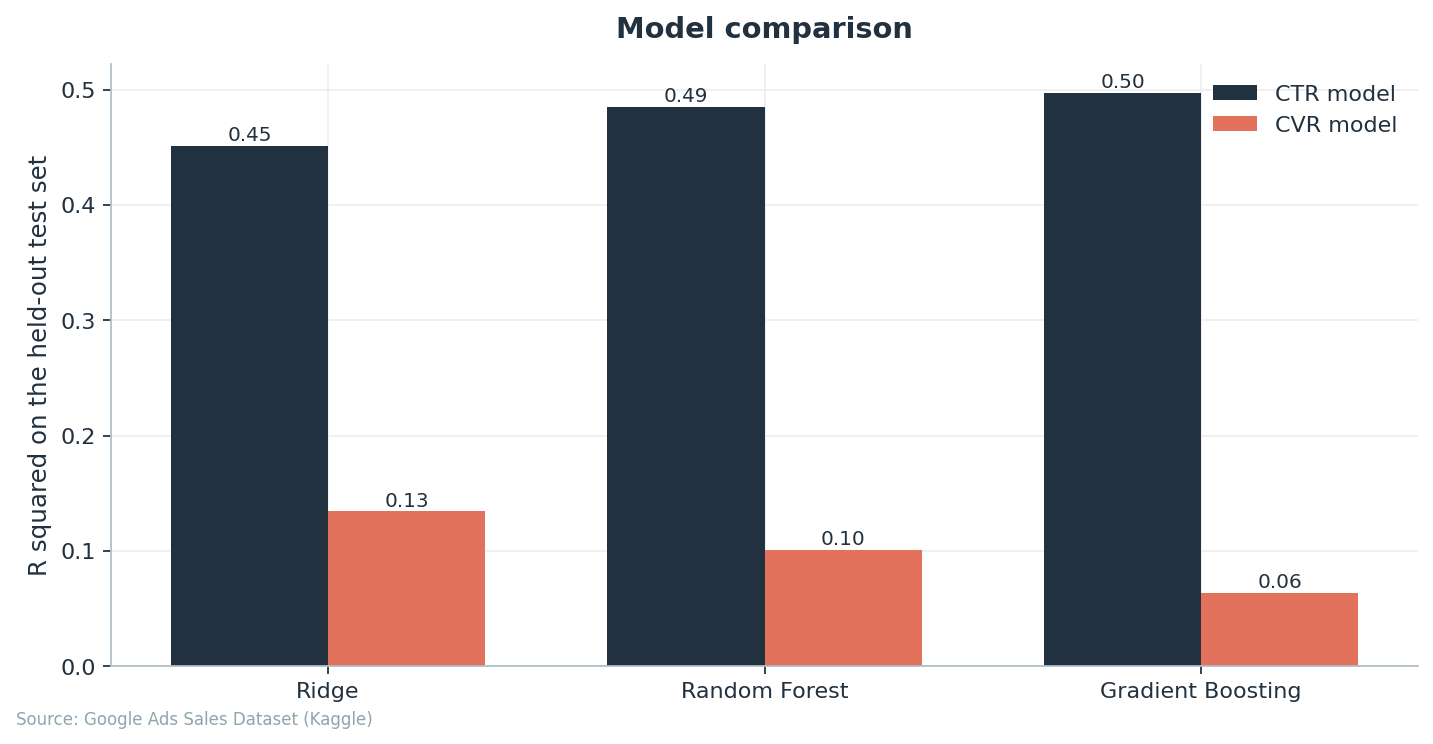

In [3]:
display(Image("reports/figures/10_model_comparison.png"))

## Which features carry the prediction

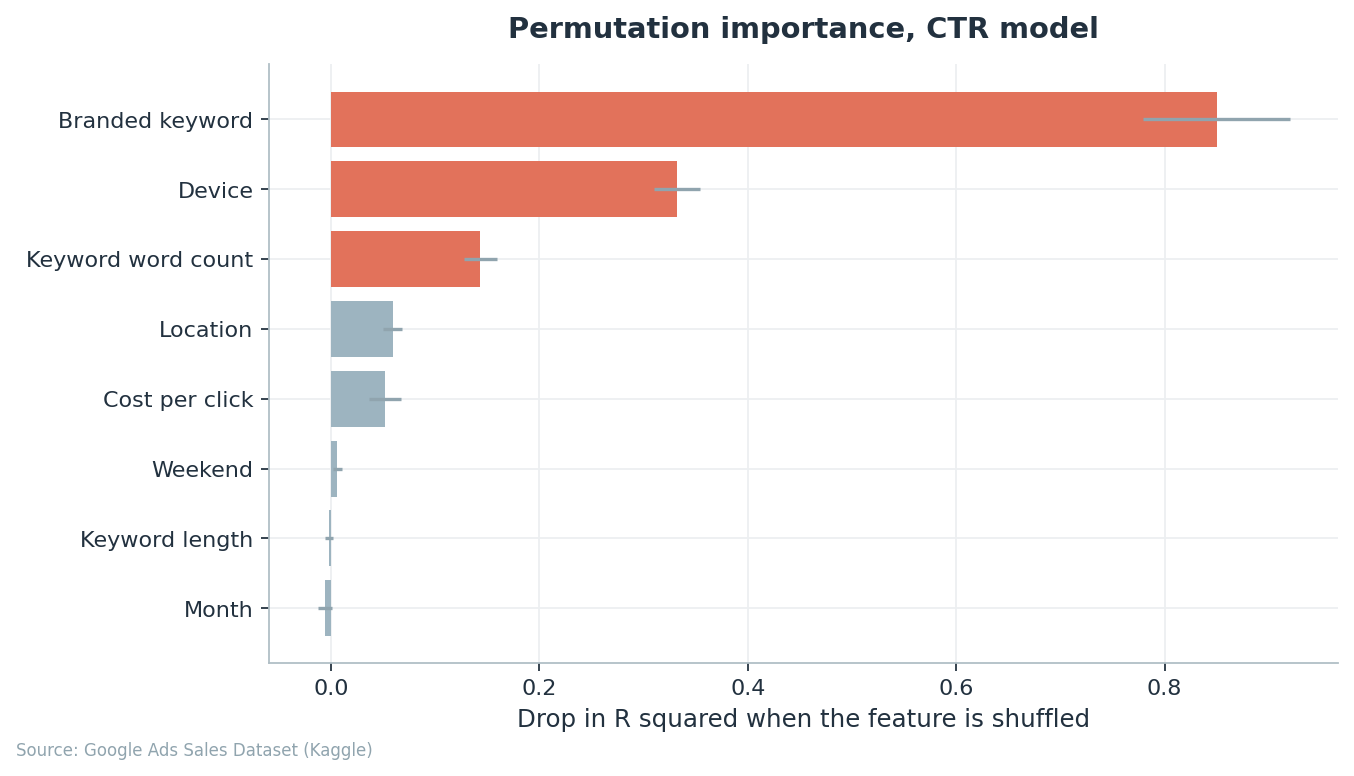

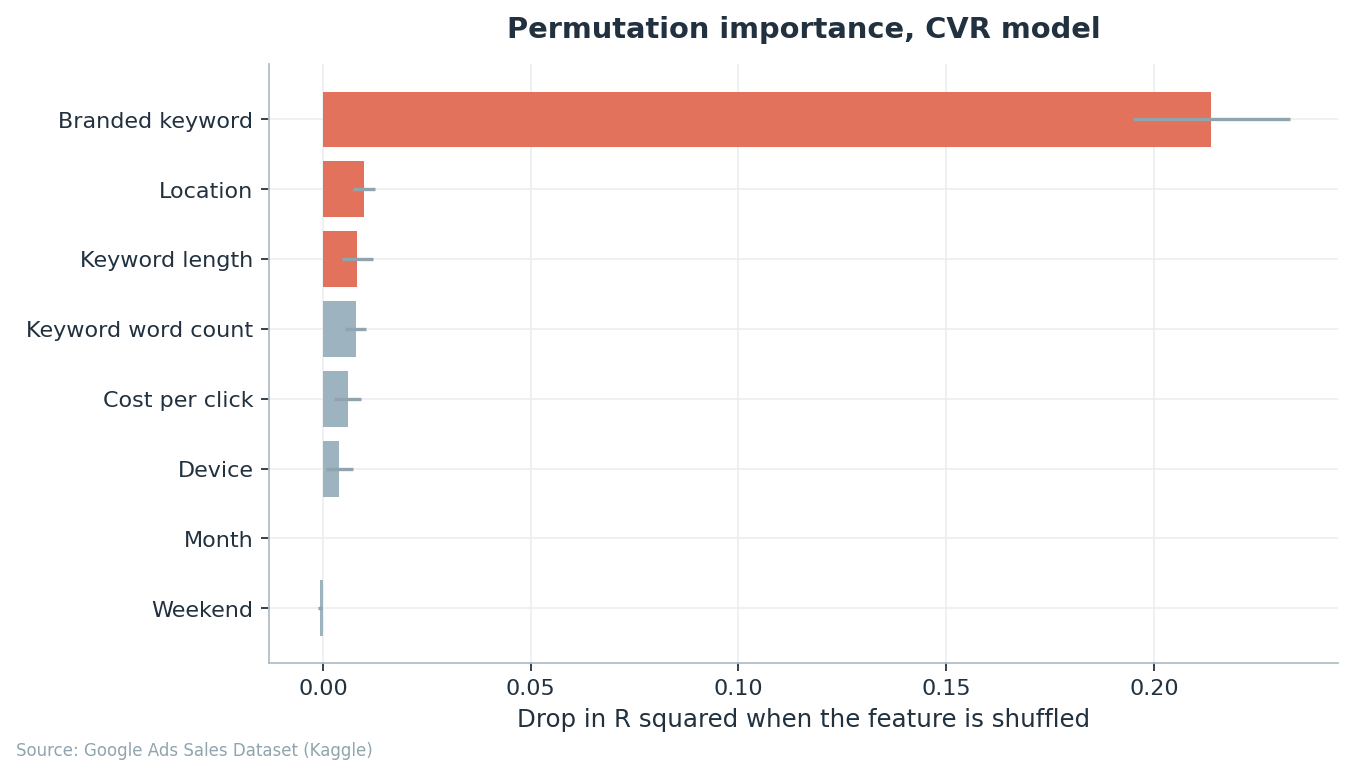

In [4]:
display(Image("reports/figures/11_importance_ctr.png"))
display(Image("reports/figures/13_importance_cvr.png"))

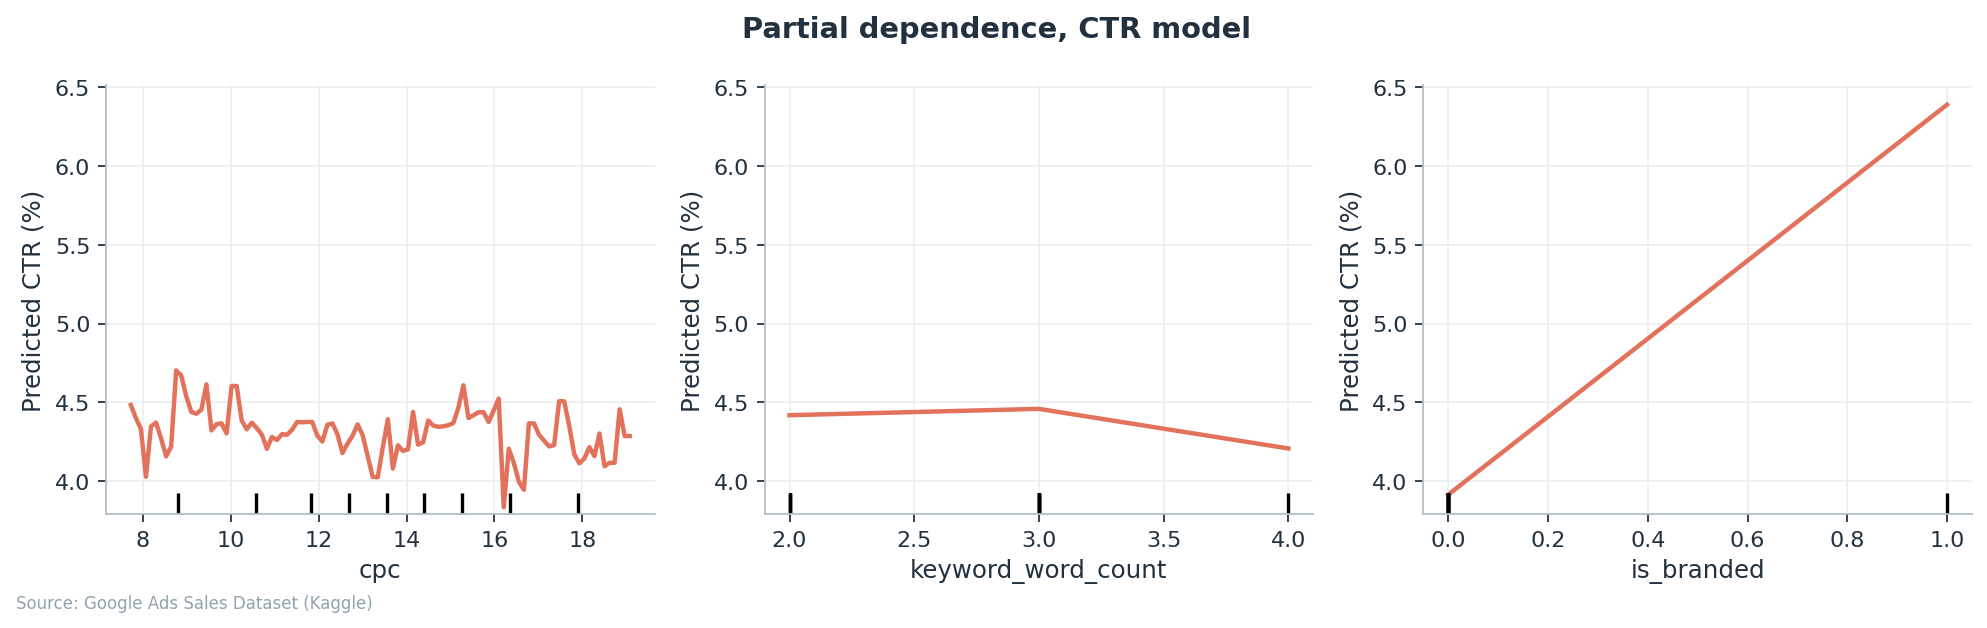

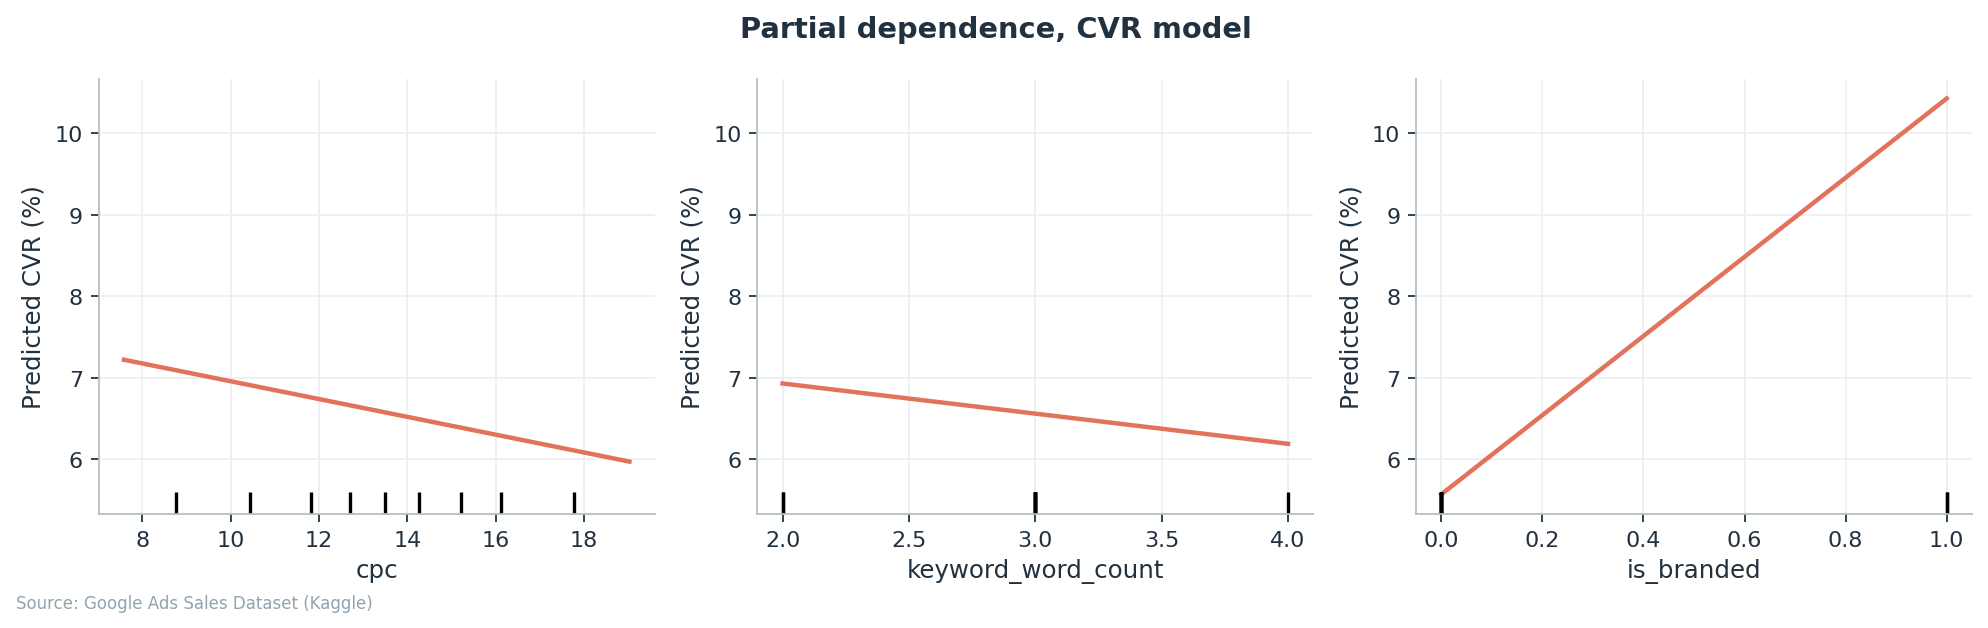

In [5]:
display(Image("reports/figures/12_pdp_ctr.png"))
display(Image("reports/figures/14_pdp_cvr.png"))

## Reading the results

CTR is considerably more predictable than CVR from this feature set. That
gap is itself a finding: clicking happens inside the search results page,
where the variables we observe (device, query type, brand affinity) live.
Converting happens after the click, on a landing page we have no features
for. With only pre-click variables, a low CVR R squared is the honest
result, not a modeling failure.

The permutation rankings agree with the regression: the branded flag and
device dominate CTR, the branded flag dominates CVR, and location plays a
secondary role. When a linear model and a boosted ensemble rank the same
drivers at the top, that agreement is worth more than either model alone.

## Findings and recommendations

**What moves CTR.** Branded intent first, device second (mobile ahead of
desktop, tablet behind), location third. A higher CPC does not buy CTR.

**What moves CVR.** Branded intent by a wide margin. Device flips: mobile
clicks convert slightly worse than desktop clicks. Longer, more specific
queries convert a little better.

**What a growth team should do with this.**

1. Report branded and non-branded performance separately. Blending them
   flatters every average and hides the true cost of growth.
2. Bid device aware: mobile earns clicks cheaply, desktop closes them.
3. Work the hidden gems quadrant first. Keywords that convert well but get
   few clicks need better copy or positions, which is cheaper than buying
   new traffic.
4. Audit the curiosity clicks quadrant for ad-to-page message match before
   renewing their budget.
5. Invest in post-click data collection. Landing page and audience features
   are what a useful CVR model is missing, not more campaign metadata.

**Limitations.** The dataset is simulated, covers a single advertiser and
one year, and aggregates at the ad level. Effects are associations under a
linear model, not causal estimates. The value of the project is the method:
the same pipeline runs unchanged on a real account export with these
columns.